# 02 — Weight Inspection

## Learning Objective
Develop intuition for **what model weights actually look like** before we start quantizing them. Understand why some layers and experts will tolerate precision reduction better than others.

## Key Concepts
- **Weight distributions:** The statistical shape of weight values determines how much information is lost during quantization. Tightly clustered weights quantize well; heavy tails and outliers do not.
- **Dynamic range:** The gap between the largest and smallest weight values in a tensor. Quantization maps this entire range onto a fixed number of bins (256 for INT8, 16 for INT4). Wider range = less precision per bin.
- **Layer-to-layer variation:** Not all layers behave the same. Layers closer to input/output, or layers with different roles (attention vs. MLP vs. routing), may have different distributions.
- **Expert variation (MoE-specific):** In a Mixture of Experts model, do all 64 experts look statistically similar, or do some have distinct weight profiles that might indicate specialization?

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer

model = AutoModelForCausalLM.from_pretrained("deepseek-ai/DeepSeek-Coder-V2-Lite-Instruct", torch_dtype=torch.bfloat16)
tokenizer = AutoTokenizer.from_pretrained("deepseek-ai/DeepSeek-Coder-V2-Lite-Instruct")

`rope_parameters`'s factor field must be a float >= 1, got 40
`rope_parameters`'s beta_fast field must be a float, got 32
`rope_parameters`'s beta_slow field must be a float, got 1


Loading weights:   0%|          | 0/351 [00:00<?, ?it/s]

`rope_parameters`'s factor field must be a float >= 1, got 40
`rope_parameters`'s beta_fast field must be a float, got 32
`rope_parameters`'s beta_slow field must be a float, got 1


### We'll begin by loading and inspecting the first layer (the dense layer, not MoE)

In [3]:
print(model.model.layers[0].self_attn.q_proj.weight)

Parameter containing:
tensor([[-0.0503,  0.0027,  0.0378,  ..., -0.0222, -0.0022, -0.0020],
        [ 0.0198,  0.0103,  0.0076,  ..., -0.0029,  0.0034, -0.0396],
        [-0.0371, -0.0082,  0.0239,  ..., -0.0100, -0.0126,  0.0447],
        ...,
        [ 0.0400, -0.0261,  0.0078,  ...,  0.0292, -0.0708,  0.0208],
        [-0.0684, -0.0400,  0.0046,  ..., -0.0659,  0.0466, -0.0240],
        [-0.0297,  0.0051,  0.0109,  ...,  0.0288,  0.0449, -0.0107]],
       dtype=torch.bfloat16, requires_grad=True)


In [ ]:
# l0 == layer zero
l0 = model.model.layers[0].self_attn.q_proj.weight.detach().float().np().flatten()

In [ ]:
gpu_tensor = torch.tensor(l0, device='cpu')
np_array = gpu_tensor.detach().float().np().flatten()

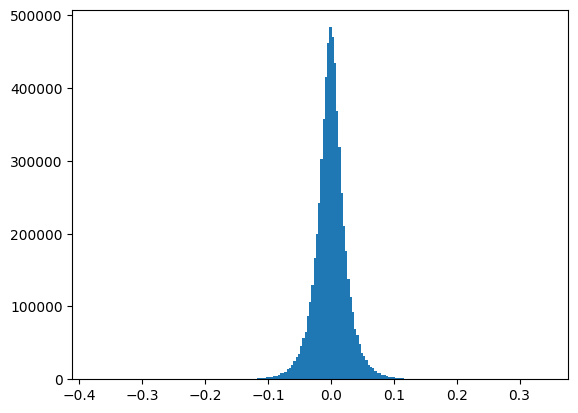

In [ ]:
plt.hist(np_array, bins=200)
plt.show()

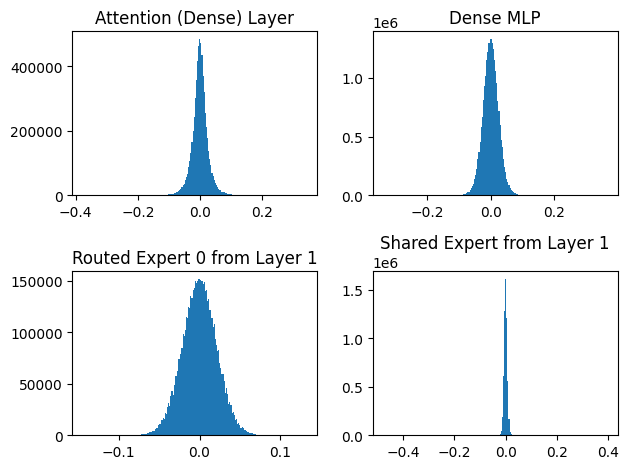

In [84]:
# Make a 2x2 subplot figure
plt.subplot(2, 2, 1)
plt.hist(model.model.layers[0].self_attn.q_proj.weight.detach().float().numpy().flatten(), bins=200)
plt.title("Attention (Dense) Layer")

plt.subplot(2, 2, 2)
plt.hist(model.model.layers[0].mlp.gate_proj.weight.detach().float().numpy().flatten(), bins=200)
plt.title("Dense MLP")

plt.subplot(2, 2, 3)
plt.hist(model.model.layers[1].mlp.experts.gate_up_proj[0].detach().float().numpy().flatten(), bins=200)
plt.title("Routed Expert 0 from Layer 1")

plt.subplot(2, 2, 4)
plt.hist(model.model.layers[1].mlp.shared_experts.gate_proj.weight.detach().float().numpy().flatten(), bins=200)
plt.title("Shared Expert from Layer 1")

plt.tight_layout()


Write a cell that loops through all 27 layers and collects, for each layer, the standard deviation and max absolute value of the attention q_proj weights. Then plot both as line charts (x-axis = layer index, y-axis = the stat). This will tell us whether the weight scale is consistent across depth or if certain layers stand out.

Layers:  27
Standard deviations:  [np.float32(0.025743712), np.float32(0.032421857), np.float32(0.033181883), np.float32(0.032468915), np.float32(0.0317918), np.float32(0.03193249), np.float32(0.03074571), np.float32(0.03166196), np.float32(0.030976748), np.float32(0.02999223), np.float32(0.030318419), np.float32(0.029991262), np.float32(0.030301156), np.float32(0.028765922), np.float32(0.029376363), np.float32(0.02889783), np.float32(0.028747544), np.float32(0.02842772), np.float32(0.028319804), np.float32(0.02814817), np.float32(0.027332965), np.float32(0.027273722), np.float32(0.026207356), np.float32(0.026224619), np.float32(0.025945485), np.float32(0.024942983), np.float32(0.024517257)]
Max absolute values:  [np.float32(0.375), np.float32(0.3359375), np.float32(0.33203125), np.float32(0.35742188), np.float32(0.40039062), np.float32(0.2734375), np.float32(0.37109375), np.float32(0.29882812), np.float32(0.3203125), np.float32(0.328125), np.float32(0.36523438), np.float32(0.390625), 

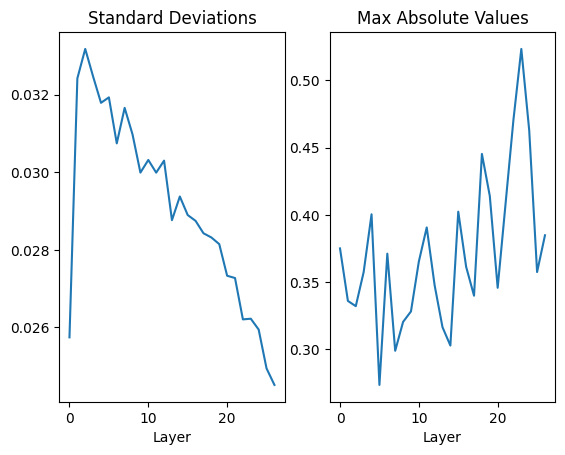

In [105]:
count = 0
std = []
max_abs = []

for layer in model.model.layers:
    count += 1
    std.append(np.std(layer.self_attn.q_proj.weight.detach().float().numpy().flatten()))
    max_abs.append(np.max(np.abs(layer.self_attn.q_proj.weight.detach().float().numpy().flatten())))

print("Layers: ", count)
print("Standard deviations: ", std)
print("Max absolute values: ", max_abs)

plt.subplot(1, 2, 1)
plt.plot(std)
plt.title("Standard Deviations")
plt.xlabel("Layer")

plt.subplot(1, 2, 2)
plt.plot(max_abs)
plt.title("Max Absolute Values")
plt.xlabel("Layer")

plt.show()

Compute the standard deviation of each expert's weights (index with [i] for expert i) and plot it as a bar chart — 64 bars, one per expert.

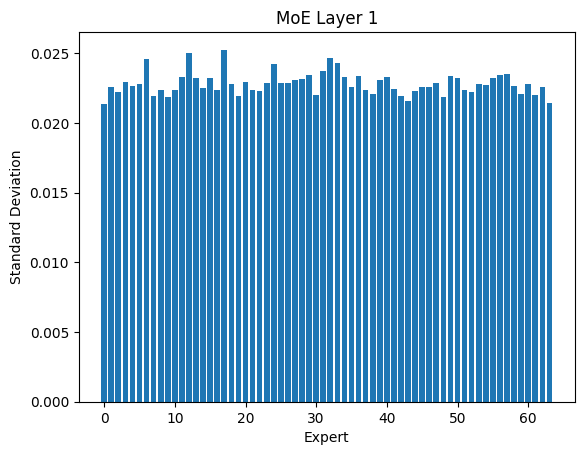

In [240]:
mylayer = 1  # Change this to select a specific MoE Layer.  Only valid on inputs between 1 and 26

experts = []
for expert in model.model.layers[mylayer].mlp.experts.gate_up_proj:
    experts.append(np.std(expert.detach().float().numpy()))

plt.bar(range(len(experts)), experts)
plt.title(f"MoE Layer {mylayer}")
plt.xlabel("Expert")
plt.ylabel("Standard Deviation")
plt.show()

#### Outlier analysis
For each of the 27 layers, compute what percentage of the attention q_proj weights fall outside ±3 standard deviations. In a perfect normal distribution, that number would be ~0.3%. If it's higher, the distribution has "heavy tails" — more outliers than expected — which is bad news for quantization.

Collect the percentages and plot them as a bar chart (one bar per layer). This connects directly to what we saw earlier: the later layers had high max abs but low std, which suggests they might have more outliers. Let's quantify it.

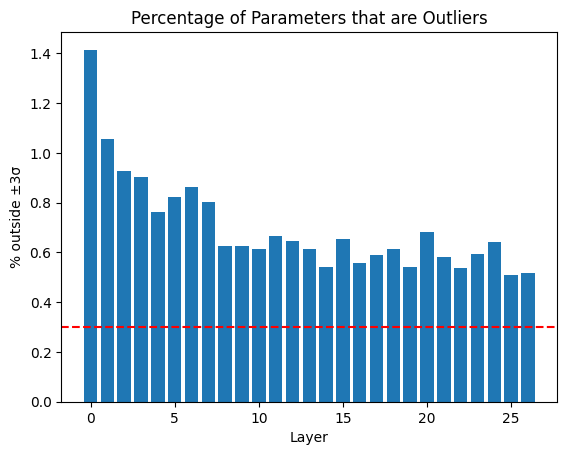

In [253]:
outlier_pct = []

for layer in model.model.layers:
    std = np.std(layer.self_attn.q_proj.weight.detach().float().numpy())
    params = layer.self_attn.q_proj.weight.detach().float().numpy().flatten()
    count = np.sum(np.abs(params) >= 3 * std)
    outlier_pct.append((count / len(params)) * 100)

plt.bar(range(len(outlier_pct)), outlier_pct)
plt.title("Percentage of Parameters that are Outliers")
plt.xlabel("Layer")
plt.ylabel("% outside ±3σ")
plt.axhline(y=0.3, color='r', linestyle='--')
plt.show()


In [263]:
for name, param in model.named_parameters():
    if any(k in name for k in ['layers.0.self_attn.q_proj', 'layers.1.mlp.experts.gate_up', 'layers.1.mlp.gate.', 'layers.0.input_layernorm']):
        print(f"{name:60s} {str(param.dtype):15s} {str(list(param.shape))}")

model.layers.0.self_attn.q_proj.weight                       torch.bfloat16  [3072, 2048]
model.layers.0.input_layernorm.weight                        torch.bfloat16  [2048]
model.layers.1.mlp.experts.gate_up_proj                      torch.bfloat16  [64, 2816, 2048]
model.layers.1.mlp.gate.weight                               torch.bfloat16  [64, 2048]


## Summary of Findings

We've learned that the layers tend to have normal distributions with varying ranges.  The attention q_proj weights in earlier layers have high standard deviations and low maximum absolute values; both of these trends reverse in the later layers.  This suggests that the earlier layers encode more general knowledge, and the later layers are more specialized.

We've also learned that each layer has a large number of outliers (at least 3 standard deviations beyond the average).  This is especially true for the earlier layers.

The named parameters are all bfloat16.  This gives us a baseline for quantization.

In [ ]:
import json, os

os.makedirs("../results", exist_ok=True)

std = []
max_abs = []
outlier_pct = []

for layer in model.model.layers:
    std.append(np.std(layer.self_attn.q_proj.weight.detach().float().numpy().flatten()))
    max_abs.append(np.max(np.abs(layer.self_attn.q_proj.weight.detach().float().numpy().flatten())))
    std_o = np.std(layer.self_attn.q_proj.weight.detach().float().numpy())
    params = layer.self_attn.q_proj.weight.detach().float().numpy().flatten()
    count = np.sum(np.abs(params) >= 3 * std_o)
    outlier_pct.append((count / len(params)) * 100)

experts = []
for expert in model.model.layers[1].mlp.experts.gate_up_proj:
    experts.append(np.std(expert.detach().float().numpy()))

stats = {
    "layer_attn_std": [float(x) for x in std],
    "layer_attn_max_abs": [float(x) for x in max_abs],
    "layer_outlier_pct": [float(x) for x in outlier_pct],
    "layer1_expert_stds": [float(x) for x in experts],  # the 64-element list
    "dtype": "bfloat16",
}

with open("../results/02_weight_stats.json", "w") as f:
    json.dump(stats, f, indent=2)

print("Variables to Track:")
print("------------------")
print("Standard deviations: ", std)
print("Maximum absolute values: ", max_abs)
print("Outlier percentages: ", outlier_pct)
print("Per-expert Standard Deviation, Layer 1: ", experts)
print("Note: all named parameters are bloat16.")

Variables to Track:
------------------
Standard deviations:  [np.float32(0.025743712), np.float32(0.032421857), np.float32(0.033181883), np.float32(0.032468915), np.float32(0.0317918), np.float32(0.03193249), np.float32(0.03074571), np.float32(0.03166196), np.float32(0.030976748), np.float32(0.02999223), np.float32(0.030318419), np.float32(0.029991262), np.float32(0.030301156), np.float32(0.028765922), np.float32(0.029376363), np.float32(0.02889783), np.float32(0.028747544), np.float32(0.02842772), np.float32(0.028319804), np.float32(0.02814817), np.float32(0.027332965), np.float32(0.027273722), np.float32(0.026207356), np.float32(0.026224619), np.float32(0.025945485), np.float32(0.024942983), np.float32(0.024517257)]
Maximum absolute values:  [np.float32(0.375), np.float32(0.3359375), np.float32(0.33203125), np.float32(0.35742188), np.float32(0.40039062), np.float32(0.2734375), np.float32(0.37109375), np.float32(0.29882812), np.float32(0.3203125), np.float32(0.328125), np.float32(0.36